In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/dsm5-control-all/dsm5_control_all.csv")

#df['DSM5_symptom'] = df['DSM5_symptom'].str.replace('_', ' ').str.capitalize()



In [258]:
df.DSM5_symptom.value_counts()

DSM5_symptom
NONE                 374
DEPRESSED_MOOD       326
WORTHLESSNESS        284
SUICIDAL_THOUGHTS    175
FATIGUE              111
ANHEDONIA            106
SLEEP_ISSUES         104
COGNITIVE_ISSUES      53
APPETITE_CHANGE       45
PSYCHOMOTOR           32
Name: count, dtype: int64

import pandas as pd
df = pd.read_csv("/kaggle/input/redsm5/redsm5_annotations.csv")
df = df[ (df["DSM5_symptom"] != "SPECIAL_CASE")].copy()
pd.set_option('display.max_colwidth', None)

In [259]:
len(df.sentence_text.unique())

1610

In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   post_id                     1610 non-null   object
 1   sentence_id                 1610 non-null   object
 2   sentence_text               1610 non-null   object
 3   DSM5_symptom                1610 non-null   object
 4   status                      1610 non-null   int64 
 5   explanation                 1610 non-null   object
 6   Qwen2.5-1.5B-Instruct       1572 non-null   object
 7   Qwen2.5-3B-Instruct         1602 non-null   object
 8   Qwen2.5-7B-Instruct         1605 non-null   object
 9   Qwen2.5-14B-Instruct        1610 non-null   object
 10  Llama-3.2-1B-Instruct       1608 non-null   object
 11  Llama-3.2-3B-Instruct       1603 non-null   object
 12  Mistral-7B-Instruct-v0.3    1523 non-null   object
 13  Mistral-Nemo-Instruct-2407  1601 non-null   obje

In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   post_id                     1610 non-null   object
 1   sentence_id                 1610 non-null   object
 2   sentence_text               1610 non-null   object
 3   DSM5_symptom                1610 non-null   object
 4   status                      1610 non-null   int64 
 5   explanation                 1610 non-null   object
 6   Qwen2.5-1.5B-Instruct       1572 non-null   object
 7   Qwen2.5-3B-Instruct         1602 non-null   object
 8   Qwen2.5-7B-Instruct         1605 non-null   object
 9   Qwen2.5-14B-Instruct        1610 non-null   object
 10  Llama-3.2-1B-Instruct       1608 non-null   object
 11  Llama-3.2-3B-Instruct       1603 non-null   object
 12  Mistral-7B-Instruct-v0.3    1523 non-null   object
 13  Mistral-Nemo-Instruct-2407  1601 non-null   obje

In [3]:
len(df.sentence_text.unique())

1610

In [263]:
df.status.value_counts()

status
1    1236
0     374
Name: count, dtype: int64

anno.sample(10)

anno[anno["sentence_text"]=="I want to succeed, but my low confidence tells me that I'm going to fail."]

In [264]:
df.columns

Index(['post_id', 'sentence_id', 'sentence_text', 'DSM5_symptom', 'status',
       'explanation', 'Qwen2.5-1.5B-Instruct', 'Qwen2.5-3B-Instruct',
       'Qwen2.5-7B-Instruct', 'Qwen2.5-14B-Instruct', 'Llama-3.2-1B-Instruct',
       'Llama-3.2-3B-Instruct', 'Mistral-7B-Instruct-v0.3',
       'Mistral-Nemo-Instruct-2407'],
      dtype='object')

In [265]:
df.DSM5_symptom.value_counts()

DSM5_symptom
NONE                 374
DEPRESSED_MOOD       326
WORTHLESSNESS        284
SUICIDAL_THOUGHTS    175
FATIGUE              111
ANHEDONIA            106
SLEEP_ISSUES         104
COGNITIVE_ISSUES      53
APPETITE_CHANGE       45
PSYCHOMOTOR           32
Name: count, dtype: int64

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, cohen_kappa_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-paper')

output_dir = Path('analysis_results')
output_dir.mkdir(exist_ok=True)


# ── Symptom name formatting ───────────────────────────────────────────────────
def format_symptom_name(symptom):
    """Convert UPPERCASE_WITH_UNDERSCORES to sentence case (first word capitalized only)."""
    if pd.isna(symptom):
        return symptom
    symptom = str(symptom)
    # Replace underscores with spaces and convert to lowercase
    symptom = symptom.replace('_', ' ').lower()
    # Capitalize only the first letter
    return symptom.capitalize()


def preprocess_dataframe(df):
    """Format symptom names in DSM5_symptom column and all model columns."""
    df = df.copy()
    
    # Format DSM5_symptom column
    df['DSM5_symptom'] = df['DSM5_symptom'].apply(format_symptom_name)
    
    # Format all model prediction columns
    model_cols = [col for col in df.columns if col not in 
                  ['sentence_id', 'sentence_text', 'DSM5_symptom']]
    
    for col in model_cols:
        df[col] = df[col].apply(format_symptom_name)
    
    return df


# ── Shared ordering & colour palette ──────────────────────────────────────────
def get_model_order_and_palette(model_cols):
    order   = sorted(model_cols)
    palette = dict(zip(order, sns.color_palette("husl", len(order))))
    return order, palette


# ── Metric calculations ───────────────────────────────────────────────────────
def calculate_f1_per_symptom(df, model_cols):
    """F1, FPR, FNR for every symptom × model. Ignores None predictions."""
    results  = []
    symptoms = df['DSM5_symptom'].dropna().unique()

    for model in model_cols:
        for symptom in symptoms:
            mask = df['DSM5_symptom'].notna() & df[model].notna()
            if mask.sum() == 0:
                continue

            y_true = (df.loc[mask, 'DSM5_symptom'] == symptom).astype(int)
            y_pred = (df.loc[mask, model]           == symptom).astype(int)

            tp = ((y_true == 1) & (y_pred == 1)).sum()
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            tn = ((y_true == 0) & (y_pred == 0)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()

            results.append({
                'Model':          model,
                'Symptom':        symptom,
                'F1_Score':       f1_score(y_true, y_pred, zero_division=0),
                'FPR':            fp / (fp + tn) if (fp + tn) > 0 else 0,
                'FNR':            fn / (fn + tp) if (fn + tp) > 0 else 0,
                'Sample_Size':    mask.sum(),
                'True_Positives': tp,
                'False_Positives':fp,
                'True_Negatives': tn,
                'False_Negatives':fn,
            })

    return pd.DataFrame(results)


def calculate_cohen_kappa(df, model_cols):
    """Cohen's Kappa and Macro F1 per model. Ignores None predictions."""
    rows = []
    for model in model_cols:
        mask = df['DSM5_symptom'].notna() & df[model].notna()
        if mask.sum() == 0:
            rows.append({'Model': model, 'Cohen_Kappa': np.nan,
                         'Macro_F1': np.nan, 'Valid_Samples': 0})
            continue
        y_true = df.loc[mask, 'DSM5_symptom']
        y_pred = df.loc[mask, model]
        rows.append({
            'Model':         model,
            'Cohen_Kappa':   cohen_kappa_score(y_true, y_pred),
            'Macro_F1':      f1_score(y_true, y_pred, average='macro', zero_division=0),
            'Valid_Samples': mask.sum(),
        })
    return pd.DataFrame(rows)


def analyze_misclassifications(df, model_cols):
    """All misclassified rows with sentence text, true label, predicted label."""
    parts = []
    for model in model_cols:
        mask = (df['DSM5_symptom'].notna() & df[model].notna() &
                (df['DSM5_symptom'] != df[model]))
        sub  = df.loc[mask, ['sentence_id', 'sentence_text', 'DSM5_symptom', model]].copy()
        sub.columns = ['sentence_id', 'sentence_text', 'True_Label', 'Predicted_Label']
        sub['Model'] = model
        parts.append(sub)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


# ── Plots ─────────────────────────────────────────────────────────────────────
def _heatmap(pivot_df, title, cmap, cbar_label, model_order, save_path):
    if model_order is not None:
        pivot_df = pivot_df.reindex(columns=model_order)
    fig, ax = plt.subplots(figsize=(12, max(8, len(pivot_df) * 0.4)))
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap=cmap,
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                cbar_kws={'label': cbar_label})
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Model',        fontsize=16, fontweight='bold')
    plt.ylabel('DSM-5 Symptom', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=13)
    plt.yticks(rotation=0,             fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def plot_f1_scores(f1_df, model_order=None, model_palette=None, save_path=None):
    pivot = f1_df.pivot(index='Symptom', columns='Model', values='F1_Score')
    return _heatmap(pivot, 'F1 Scores by Symptom and Model',
                    'RdYlGn', 'F1 Score', model_order, save_path)


def plot_fpr_heatmap(f1_df, model_order=None, model_palette=None, save_path=None):
    pivot = f1_df.pivot(index='Symptom', columns='Model', values='FPR')
    return _heatmap(pivot, 'False Positive Rate by Symptom and Model',
                    'RdYlGn_r', 'FPR', model_order, save_path)


def plot_fnr_heatmap(f1_df, model_order=None, model_palette=None, save_path=None):
    pivot = f1_df.pivot(index='Symptom', columns='Model', values='FNR')
    return _heatmap(pivot, 'False Negative Rate by Symptom and Model',
                    'RdYlGn_r', 'FNR', model_order, save_path)


def _bar(ax, models, values, colors, title, ylabel):
    bars = ax.bar(range(len(models)), values,
                  color=colors, edgecolor='black', linewidth=1.2)
    for bar, val in zip(bars, values):
        if val is not None and not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                    f'{val:.3f}', ha='center', va='bottom',
                    fontweight='bold', fontsize=10)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=13)
    ax.set_xlabel('Model',  fontsize=16, fontweight='bold')
    ax.set_ylabel(ylabel,   fontsize=16, fontweight='bold')
    ax.set_title(title,     fontsize=14, fontweight='bold', pad=20)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)


def plot_average_f1_by_model(f1_df, model_order=None, model_palette=None, save_path=None):
    avg = f1_df.groupby('Model')['F1_Score'].mean()
    if model_order is not None:
        avg = avg.reindex(model_order)
    colors = ([model_palette[m] for m in avg.index]
              if model_palette else sns.color_palette("husl", len(avg)))
    fig, ax = plt.subplots(figsize=(10, 6))
    _bar(ax, avg.index.tolist(), avg.values,
         colors, 'Average F1 Score Across All Symptoms by Model', 'Average F1 Score')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def plot_kappa_scores(kappa_df, model_order=None, model_palette=None, save_path=None):
    if model_order is not None:
        kappa_df = kappa_df.set_index('Model').reindex(model_order).reset_index()
    colors = ([model_palette[m] for m in kappa_df['Model']]
              if model_palette else sns.color_palette("husl", len(kappa_df)))
    fig, ax = plt.subplots(figsize=(10, 6))
    _bar(ax, kappa_df['Model'].tolist(), kappa_df['Cohen_Kappa'].tolist(),
         colors, "Cohen's Kappa: Agreement between Models and DSM-5 Labels", "Cohen's Kappa")
    ax.axhline(y=0.6, color='red',   linestyle='--', alpha=0.5, label='Substantial (κ=0.6)')
    ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Almost Perfect (κ=0.8)')
    ax.legend(loc='lower right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def plot_macro_f1_comparison(kappa_df, model_order=None, model_palette=None, save_path=None):
    if model_order is not None:
        kappa_df = kappa_df.set_index('Model').reindex(model_order).reset_index()
    colors = ([model_palette[m] for m in kappa_df['Model']]
              if model_palette else sns.color_palette("husl", len(kappa_df)))
    fig, ax = plt.subplots(figsize=(10, 6))
    _bar(ax, kappa_df['Model'].tolist(), kappa_df['Macro_F1'].tolist(),
         colors, 'Macro F1 Score by Model (Average Across All Symptoms)', 'Macro F1 Score')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def plot_kappa_macro_f1_comparison(kappa_df, model_order=None, model_palette=None, save_path=None):
    """Grouped bar plot comparing Cohen's Kappa and Macro F1."""
    # Sort by Cohen's Kappa (descending)
    kappa_df = kappa_df.sort_values('Cohen_Kappa', ascending=False).reset_index(drop=True)
    
    colors = ([model_palette[m] for m in kappa_df['Model']]
              if model_palette else sns.color_palette("husl", len(kappa_df)))

    fig, ax1 = plt.subplots(figsize=(11, 7))
    fig.suptitle("Model Performance: Cohen's Kappa vs Macro F1",
                 fontsize=15, fontweight='bold')

    x, w = np.arange(len(kappa_df)), 0.35
    b1 = ax1.bar(x - w/2, kappa_df['Cohen_Kappa'], w,
                 label="Cohen's Kappa", color=colors,
                 edgecolor='black', linewidth=1.2)
    b2 = ax1.bar(x + w/2, kappa_df['Macro_F1'], w,
                 label='Macro F1', color=colors,
                 edgecolor='black', linewidth=1.2, alpha=0.5,
                 hatch='//')
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h) and h > 0:
                ax1.text(bar.get_x() + bar.get_width() / 2., h + 0.015,
                         f'{h:.3f}', ha='center', va='bottom',
                         fontsize=9, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(kappa_df['Model'], rotation=40, ha='right', fontsize=12)
    ax1.set_xlabel('Model',  fontsize=16, fontweight='bold')
    ax1.set_ylabel('Score',  fontsize=16, fontweight='bold')
    ax1.set_ylim(0, 0.85)
    ax1.axhline(0.6, color='red',   linestyle='--', alpha=0.4, linewidth=1.2, label='Substantial (κ=0.6)')
    ax1.axhline(0.8, color='green', linestyle='--', alpha=0.4, linewidth=1.2, label='Almost Perfect (κ=0.8)')
    ax1.legend(fontsize=10, loc='upper right')
    ax1.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig

def plot_symptom_f1_bar_NEW(
    f1_df,
    model_order=None,
    model_palette=None,
    save_path="figure.png",   # default PNG
    two_column=False,
    dpi=300                  # high-res for papers
):
    """Grouped bar chart optimized for two-column publication layout (PNG export)."""

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ---- 1. Model order & colors ----
    if model_order is None:
        model_order = sorted(f1_df['Model'].unique())

    colors = ([model_palette[m] for m in model_order]
              if model_palette else sns.color_palette("husl", len(model_order)))

    symptoms = sorted(f1_df['Symptom'].unique())
    x = np.arange(len(symptoms))
    n = len(model_order)

    # ---- 2. Figure size ----
    figsize = (7.2, 3.5) if two_column else (3.5, 2.8)

    plt.rcParams.update({
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7
    })

    fig, ax = plt.subplots(figsize=figsize)

    # ---- 3. Bar width ----
    w = 0.6 / n

    # ---- 4. Plot ----
    for i, (model, color) in enumerate(zip(model_order, colors)):
        vals = [
            f1_df.loc[
                (f1_df['Model'] == model) & (f1_df['Symptom'] == s),
                'F1_Score'
            ].values
            for s in symptoms
        ]
        vals = [v[0] if len(v) > 0 else 0 for v in vals]

        offset = (i - n / 2 + 0.5) * w

        ax.bar(x + offset, vals, w,
               label=model,
               color=color,
               edgecolor='black',
               linewidth=0.5)

    # ---- 5. X-axis labels ----
    if len(symptoms) > 12:
        step = max(1, len(symptoms) // 10)
        ax.set_xticks(x[::step])
        ax.set_xticklabels([symptoms[i] for i in range(0, len(symptoms), step)],
                           rotation=60, ha='right')
    else:
        ax.set_xticks(x)
        ax.set_xticklabels(symptoms, rotation=45, ha='right')

    # ---- 6. Styling ----
    ax.set_xlabel('DSM-5 Symptom')
    ax.set_ylabel('F1 Score')
    ax.set_title('Symptom-wise F1 Score by Model')
    ax.set_ylim(0, 1.1)

    ax.legend(ncol=2, frameon=False)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    # ---- 7. Save PNG ----
    if save_path:
        if not save_path.endswith(".png"):
            save_path += ".png"
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()
    return fig
def plot_symptom_f1_bar(f1_df, model_order=None, model_palette=None, save_path=None):
    """Grouped bar chart: F1 score for every symptom, grouped by model."""
    if model_order is None:
        model_order = sorted(f1_df['Model'].unique())
    colors = ([model_palette[m] for m in model_order]
              if model_palette else sns.color_palette("husl", len(model_order)))

    symptoms = sorted(f1_df['Symptom'].unique())
    x        = np.arange(len(symptoms))
    n        = len(model_order)
    w        = 0.8 / n

    fig, ax = plt.subplots(figsize=(max(16, len(symptoms) * 1.4), 8))
    for i, (model, color) in enumerate(zip(model_order, colors)):
        vals = [f1_df.loc[(f1_df['Model'] == model) &
                          (f1_df['Symptom'] == s), 'F1_Score'].values
                for s in symptoms]
        vals   = [v[0] if len(v) > 0 else 0 for v in vals]
        offset = (i - n / 2 + 0.5) * w
        ax.bar(x + offset, vals, w,
               label=model, color=color, edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(symptoms, rotation=45, ha='right', fontsize=24, fontweight='bold')
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlabel('DSM-5 Symptom', fontsize=22, fontweight='bold', labelpad=10)
    ax.set_ylabel('F1 Score',      fontsize=22, fontweight='bold', labelpad=10)
    ax.set_title('Symptom-wise F1 Score by Model',
                 fontsize=17, fontweight='bold', pad=15)
    ax.set_ylim(0, 1.15)
    ax.legend(title='Model', fontsize=13, title_fontsize=14,
              loc='upper right', ncol=2)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def plot_symptom_fnr_bar(f1_df, model_order=None, model_palette=None, save_path=None):
    """Grouped bar chart: FNR for every symptom, grouped by model."""
    if model_order is None:
        model_order = sorted(f1_df['Model'].unique())
    colors = ([model_palette[m] for m in model_order]
              if model_palette else sns.color_palette("husl", len(model_order)))

    symptoms = sorted(f1_df['Symptom'].unique())
    x        = np.arange(len(symptoms))
    n        = len(model_order)
    w        = 0.8 / n

    fig, ax = plt.subplots(figsize=(max(16, len(symptoms) * 1.4), 8))
    for i, (model, color) in enumerate(zip(model_order, colors)):
        vals = [f1_df.loc[(f1_df['Model'] == model) &
                          (f1_df['Symptom'] == s), 'FNR'].values
                for s in symptoms]
        vals   = [v[0] if len(v) > 0 else 0 for v in vals]
        offset = (i - n / 2 + 0.5) * w
        ax.bar(x + offset, vals, w,
               label=model, color=color, edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(symptoms, rotation=45, ha='right', fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlabel('DSM-5 Symptom',       fontsize=22, fontweight='bold', labelpad=10)
    ax.set_ylabel('False Negative Rate', fontsize=22, fontweight='bold', labelpad=10)
    ax.set_title('Symptom-wise False Negative Rate by Model',
                 fontsize=17, fontweight='bold', pad=15)
    ax.set_ylim(0, 1.15)
    ax.legend(title='Model', fontsize=13, title_fontsize=14,
              loc='upper right', ncol=2)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def plot_misclassification_heatmap(misclass_df, save_path=None):
    if misclass_df.empty:
        print("No misclassifications found.")
        return None
    counts  = misclass_df.groupby(['Model', 'True_Label', 'Predicted_Label']).size().reset_index(name='Count')
    models  = counts['Model'].unique()
    n       = len(models)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]
    for ax, model in zip(axes, models):
        pivot = (counts[counts['Model'] == model]
                 .pivot_table(index='True_Label', columns='Predicted_Label',
                              values='Count', fill_value=0, aggfunc='sum'))
        sns.heatmap(pivot, annot=True, fmt='g', cmap='OrRd', ax=ax,
                    linewidths=0.5, cbar_kws={'label': 'Count'})
        ax.set_title(f'{model}\nMisclassification Pattern', fontweight='bold', fontsize=14)
        ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=16)
        ax.set_ylabel('True Label',      fontweight='bold', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


# ── Main report ───────────────────────────────────────────────────────────────
def generate_report(df, model_cols):
    print("=" * 80)
    print("DSM-5 SYMPTOM CLASSIFICATION ANALYSIS")
    print("=" * 80)

    # Preprocess dataframe to format symptom names
    print("\n[0/7] Preprocessing: Formatting symptom names...")
    df = preprocess_dataframe(df)
    print("✓ Symptom names formatted (e.g., 'DEPRESSED_MOOD' → 'Depressed mood')")

    model_order, model_palette = get_model_order_and_palette(model_cols)
    print(f"\nModel order used across all plots: {model_order}")

    # 1. Per-symptom metrics
    print("\n[1/7] Calculating F1, FPR, FNR per symptom...")
    f1_df = calculate_f1_per_symptom(df, model_cols)
    f1_df.to_csv(output_dir / 'f1_fpr_fnr_scores_per_symptom.csv', index=False)
    print(f"✓ Saved: {output_dir / 'f1_fpr_fnr_scores_per_symptom.csv'}")

    # 2. Kappa + Macro F1
    print("\n[2/7] Calculating Cohen's Kappa and Macro F1...")
    kappa_df = calculate_cohen_kappa(df, model_cols)
    print(kappa_df.to_string(index=False))
    kappa_df.to_csv(output_dir / 'cohen_kappa_macro_f1_scores.csv', index=False)
    print(f"✓ Saved: {output_dir / 'cohen_kappa_macro_f1_scores.csv'}")

    # 3. Misclassifications
    print("\n[3/7] Analyzing misclassifications...")
    misclass_df = analyze_misclassifications(df, model_cols)
    print(f"Total misclassifications: {len(misclass_df)}")
    if not misclass_df.empty:
        misclass_df.to_csv(output_dir / 'misclassifications.csv', index=False)
        print(f"✓ Saved: {output_dir / 'misclassifications.csv'}")

    # 4. Visualisations
    print("\n[4/7] Generating visualisations...")
    plot_f1_scores(f1_df,   model_order, model_palette, output_dir / 'f1_heatmap.png')
    plot_fpr_heatmap(f1_df, model_order, model_palette, output_dir / 'fpr_heatmap.png')
    plot_fnr_heatmap(f1_df, model_order, model_palette, output_dir / 'fnr_heatmap.png')
    plot_average_f1_by_model(f1_df,   model_order, model_palette, output_dir / 'average_f1_by_model.png')
    plot_kappa_scores(kappa_df,        model_order, model_palette, output_dir / 'cohen_kappa_plot.png')
    plot_macro_f1_comparison(kappa_df, model_order, model_palette, output_dir / 'macro_f1_comparison.png')
    plot_kappa_macro_f1_comparison(kappa_df, model_order, model_palette, output_dir / 'kappa_vs_macro_f1.png')
    plot_symptom_f1_bar(f1_df,  model_order, model_palette, output_dir / 'symptom_f1_bar.png')
    plot_symptom_f1_bar_NEW(f1_df, save_path="symptom_plotNEW.png")
    plot_symptom_fnr_bar(f1_df, model_order, model_palette, output_dir / 'symptom_fnr_bar.png')
    if not misclass_df.empty:
        plot_misclassification_heatmap(misclass_df, output_dir / 'misclassification_heatmap.png')
    print("✓ All visualisations saved.")

    # 5. Summary statistics
    print("\n[5/7] Summary statistics...")
    summary = {'Total_Samples': len(df),
               'Unique_Symptoms': df['DSM5_symptom'].nunique(),
               'Models_Evaluated': len(model_cols)}
    for m in model_cols:
        v = df[m].notna().sum()
        summary[f'{m}_Valid_Predictions'] = v
        summary[f'{m}_Coverage']          = f"{v / len(df) * 100:.2f}%"
    summary_df = pd.DataFrame([summary]).T.rename(columns={0: 'Value'})
    summary_df.to_csv(output_dir / 'summary_statistics.csv')
    print(f"✓ Saved: {output_dir / 'summary_statistics.csv'}")

    # 6. Performance summary table
    print("\n[6/7] Performance metrics summary...")
    perf = (kappa_df
            .merge(f1_df.groupby('Model')['FPR'].mean().reset_index().rename(columns={'FPR': 'Average_FPR'}), on='Model')
            .merge(f1_df.groupby('Model')['FNR'].mean().reset_index().rename(columns={'FNR': 'Average_FNR'}), on='Model')
            .merge(f1_df.groupby('Model')['F1_Score'].mean().reset_index().rename(columns={'F1_Score': 'Average_F1'}), on='Model'))
    perf = perf[['Model', 'Macro_F1', 'Average_F1', 'Cohen_Kappa',
                 'Average_FPR', 'Average_FNR', 'Valid_Samples']]
    print(perf.to_string(index=False))
    perf.to_csv(output_dir / 'performance_metrics_summary.csv', index=False)
    print(f"✓ Saved: {output_dir / 'performance_metrics_summary.csv'}")

    print("\n" + "=" * 80)
    print(f"ANALYSIS COMPLETE — results in: {output_dir}/")
    print("=" * 80)

    return {'f1_fpr_fnr': f1_df, 'kappa_macro_f1': kappa_df,
            'performance': perf, 'misclassifications': misclass_df}




DSM-5 SYMPTOM CLASSIFICATION ANALYSIS

[0/7] Preprocessing: Formatting symptom names...
✓ Symptom names formatted (e.g., 'DEPRESSED_MOOD' → 'Depressed mood')

Model order used across all plots: ['Qwen2.5-14B-Instruct', 'Qwen2.5-7B-Instruct']

[1/7] Calculating F1, FPR, FNR per symptom...
✓ Saved: analysis_results/f1_fpr_fnr_scores_per_symptom.csv

[2/7] Calculating Cohen's Kappa and Macro F1...
               Model  Cohen_Kappa  Macro_F1  Valid_Samples
 Qwen2.5-7B-Instruct     0.602929  0.648298           1605
Qwen2.5-14B-Instruct     0.599721  0.651392           1610
✓ Saved: analysis_results/cohen_kappa_macro_f1_scores.csv

[3/7] Analyzing misclassifications...
Total misclassifications: 1096
✓ Saved: analysis_results/misclassifications.csv

[4/7] Generating visualisations...


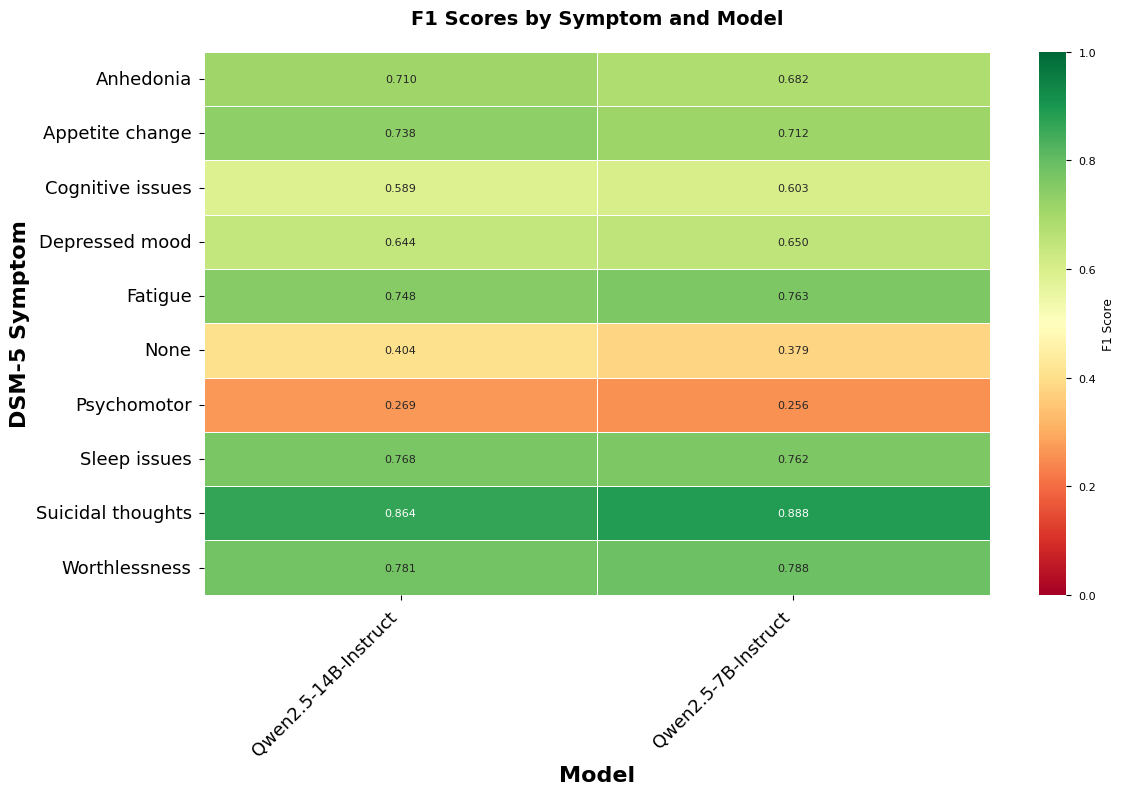

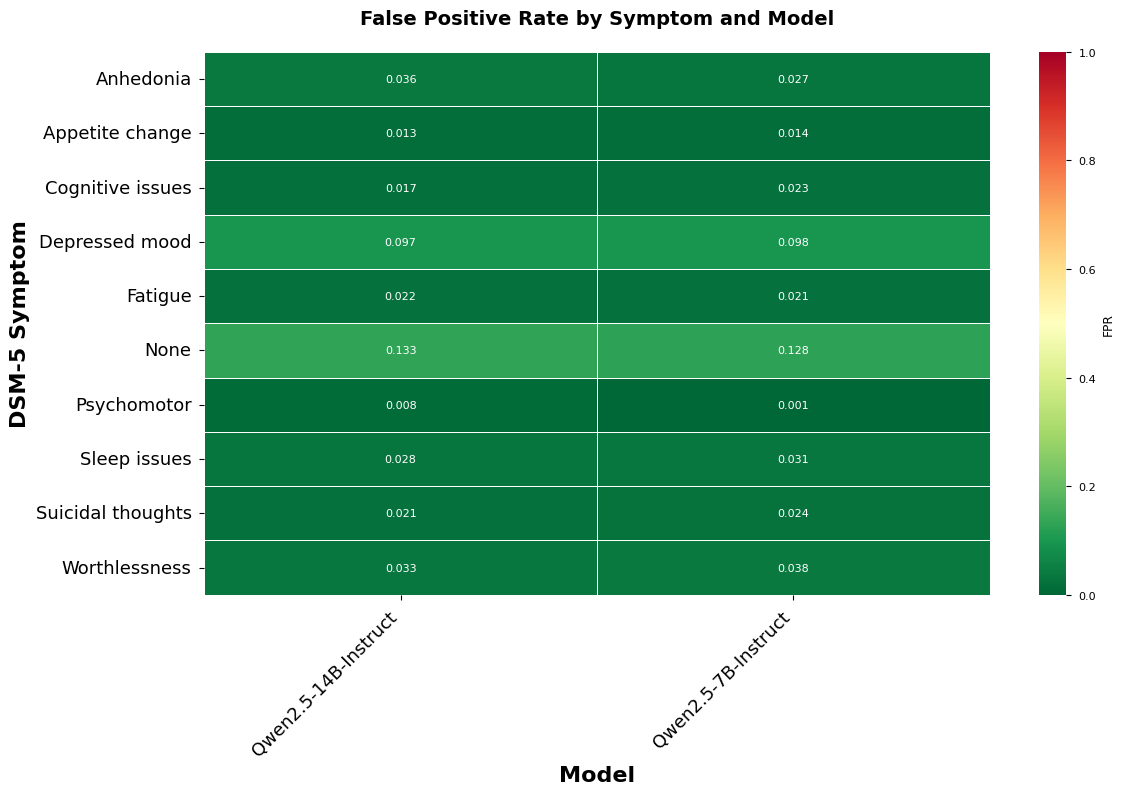

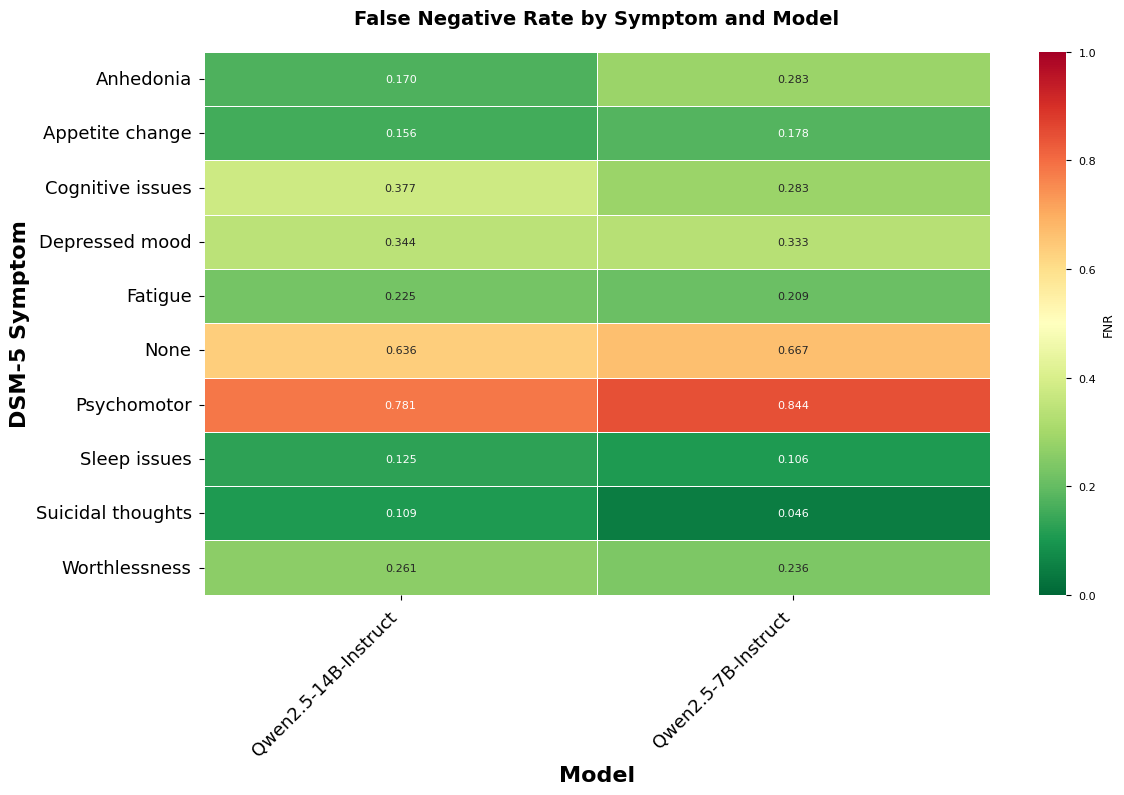

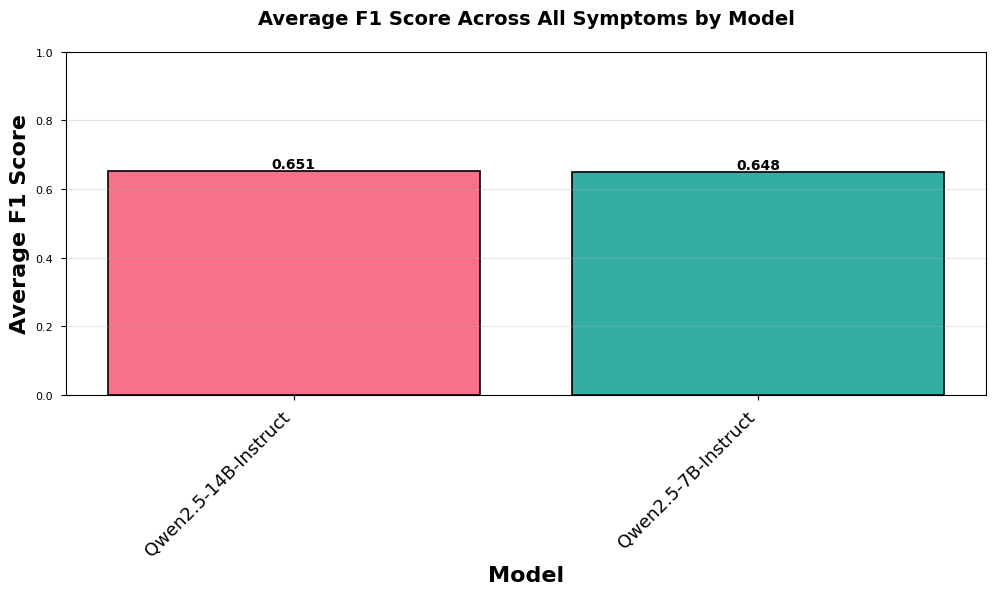

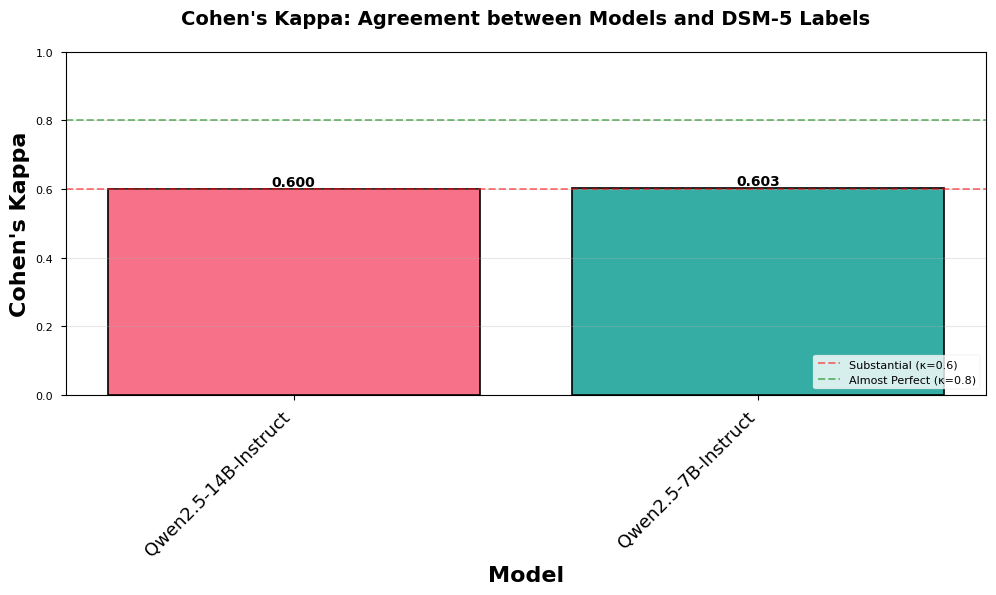

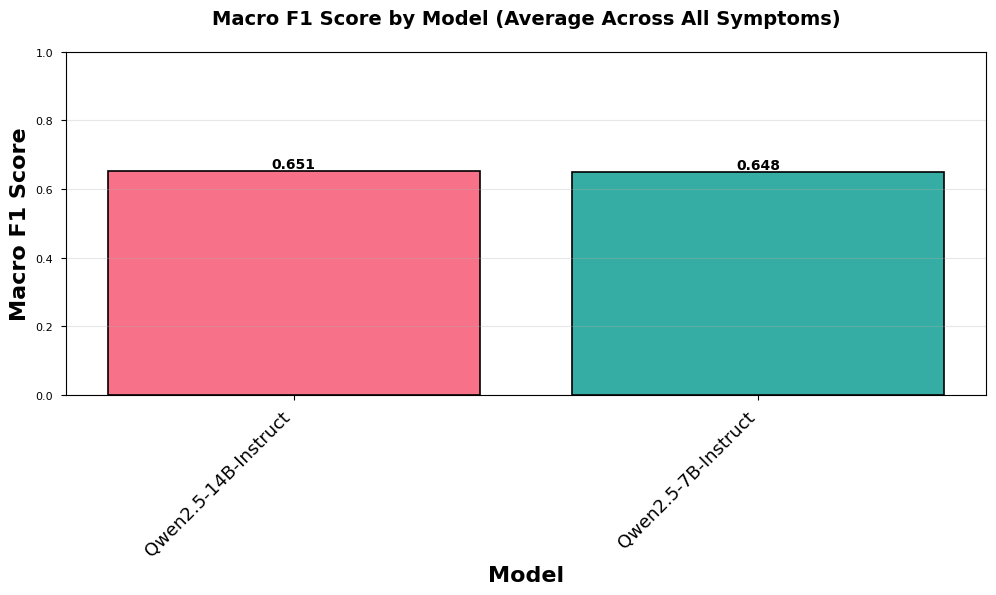

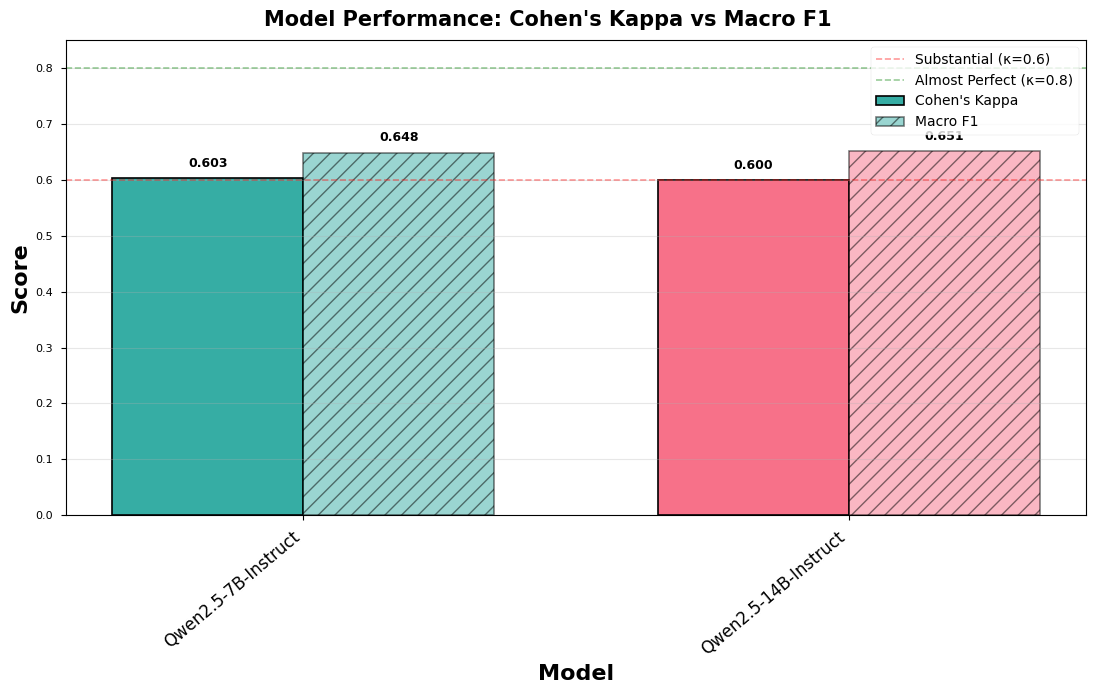

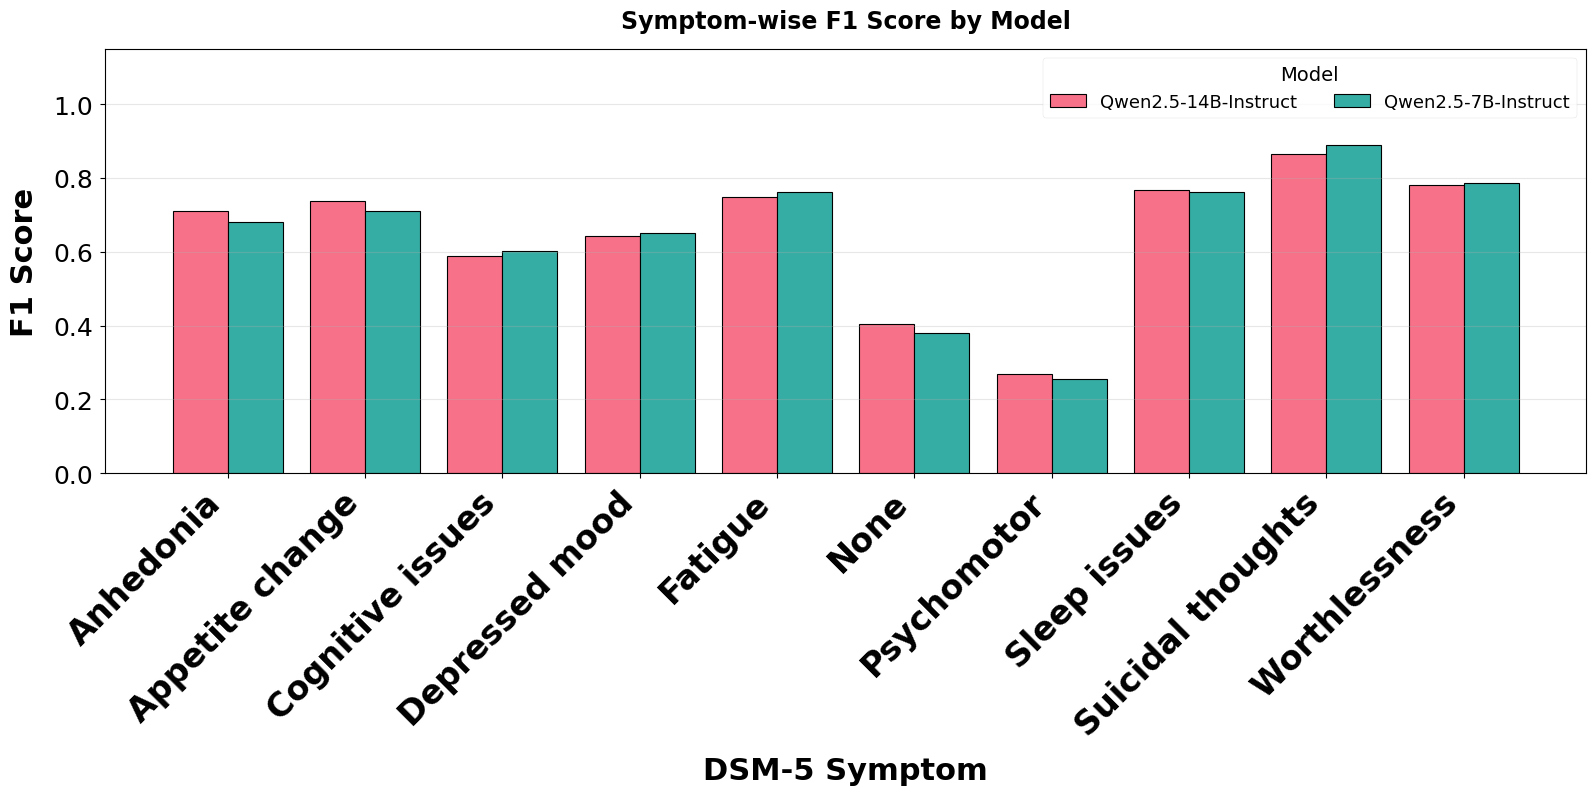

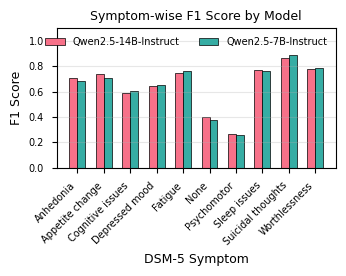

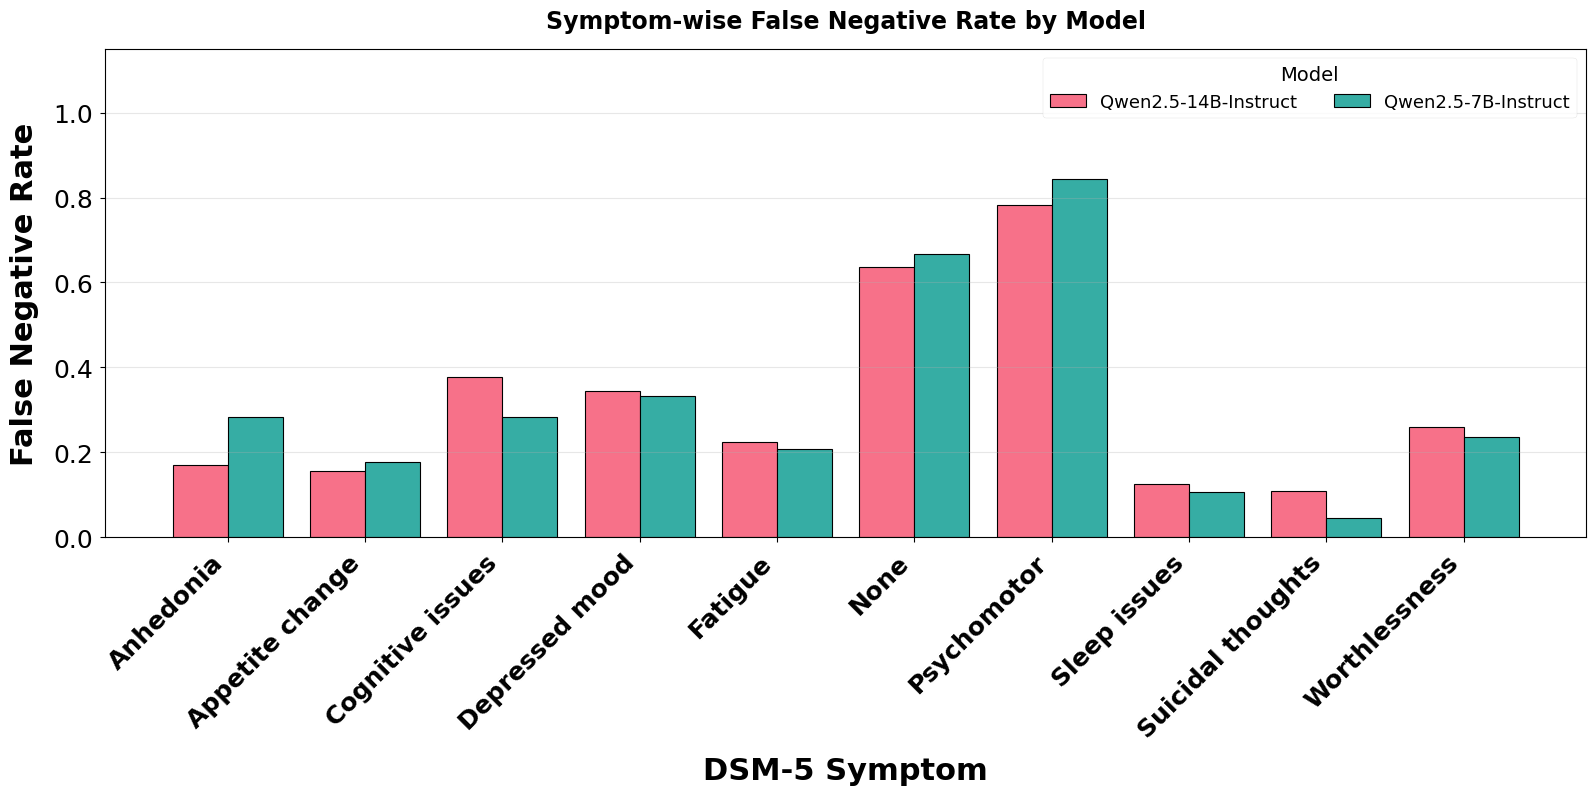

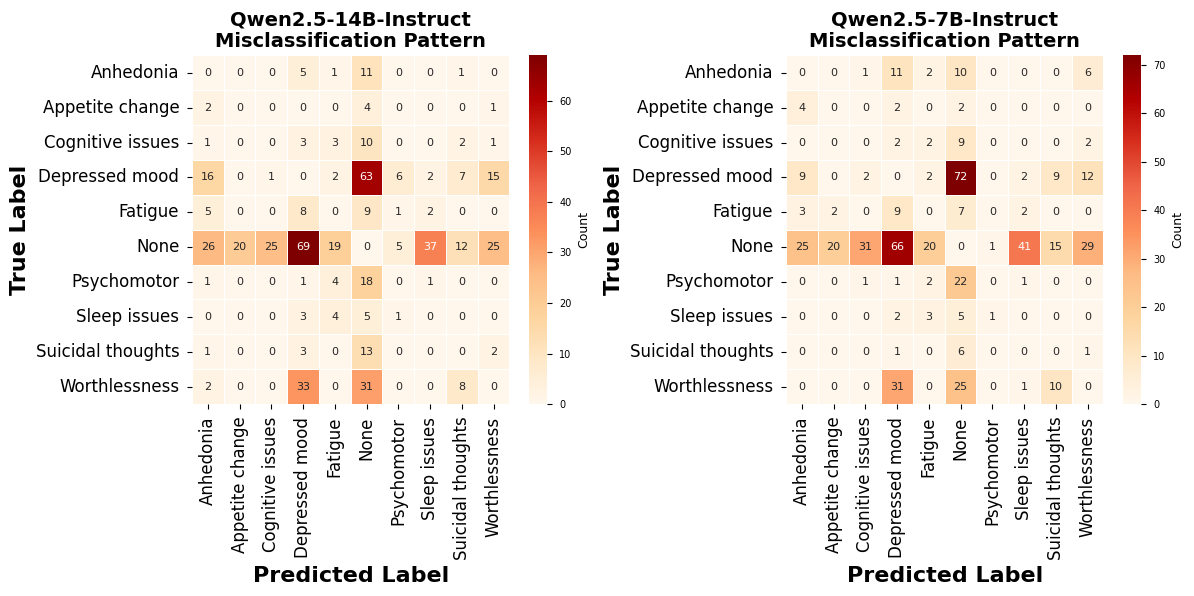

✓ All visualisations saved.

[5/7] Summary statistics...
✓ Saved: analysis_results/summary_statistics.csv

[6/7] Performance metrics summary...
               Model  Macro_F1  Average_F1  Cohen_Kappa  Average_FPR  Average_FNR  Valid_Samples
 Qwen2.5-7B-Instruct  0.648298    0.648298     0.602929     0.040467     0.318406           1605
Qwen2.5-14B-Instruct  0.651392    0.651392     0.599721     0.040765     0.318326           1610
✓ Saved: analysis_results/performance_metrics_summary.csv

ANALYSIS COMPLETE — results in: analysis_results/


In [5]:
if __name__ == "__main__":
    # Define model columns (excluding sentence_id, sentence_text, and DSM5_symptom)
    model_cols = [
    #"Qwen2.5-1.5B-Instruct",
    #"Qwen2.5-3B-Instruct",
    "Qwen2.5-7B-Instruct",
    "Qwen2.5-14B-Instruct",
    #"Llama-3.2-1B-Instruct",
    #"Llama-3.2-3B-Instruct",
    #"Mistral-7B-Instruct-v0.3",
    #"Mistral-Nemo-Instruct-2407"
]
    
    # Run the analysis
    
    results = generate_report(df, model_cols)



In [268]:
fnr = pd.read_csv("analysis_results/f1_fpr_fnr_scores_per_symptom.csv")

In [269]:
fnr.columns

Index(['Model', 'Symptom', 'F1_Score', 'FPR', 'FNR', 'Sample_Size',
       'True_Positives', 'False_Positives', 'True_Negatives',
       'False_Negatives'],
      dtype='object')

In [271]:
fnr  #[fnr['Symptom'] != 'NONE']

,Model,Symptom,F1_Score,FPR,FNR,Sample_Size,True_Positives,False_Positives,True_Negatives,False_Negatives
0,Qwen2.5-7B-Instruct,Sleep issues,0.762295,0.031312,0.105769,1605,93,47,1454,11
1,Qwen2.5-7B-Instruct,NaN,0.379205,0.128143,0.666667,1605,124,158,1075,248
2,Qwen2.5-7B-Instruct,Fatigue,0.763158,0.020736,0.209091,1605,87,31,1464,23
3,Qwen2.5-7B-Instruct,Cognitive issues,0.603175,0.022552,0.283019,1605,38,35,1517,15
4,Qwen2.5-7B-Instruct,Depressed mood,0.649624,0.097580,0.333333,1605,216,125,1156,108
5,Qwen2.5-7B-Instruct,Anhedonia,0.681614,0.027352,0.283019,1605,76,41,1458,30
6,Qwen2.5-7B-Instruct,Worthlessness,0.787659,0.037850,0.235915,1605,217,50,1271,67
7,Qwen2.5-7B-Instruct,Suicidal thoughts,0.888298,0.023776,0.045714,1605,167,34,1396,8
8,Qwen2.5-7B-Instruct,Psychomotor,0.256410,0.001271,0.843750,1605,5,2,1571,27
9,Qwen2.5-7B-Instruct,Appetite change,0.711538,0.014103,0.177778,1605,37,22,1538,8


In [272]:
fnr[["Model", 'Symptom', "FNR"]].sort_values(by=['Symptom',"FNR"])

,Model,Symptom,FNR
5,Qwen2.5-7B-Instruct,Anhedonia,0.283019
9,Qwen2.5-7B-Instruct,Appetite change,0.177778
3,Qwen2.5-7B-Instruct,Cognitive issues,0.283019
4,Qwen2.5-7B-Instruct,Depressed mood,0.333333
2,Qwen2.5-7B-Instruct,Fatigue,0.209091
8,Qwen2.5-7B-Instruct,Psychomotor,0.843750
0,Qwen2.5-7B-Instruct,Sleep issues,0.105769
7,Qwen2.5-7B-Instruct,Suicidal thoughts,0.045714
6,Qwen2.5-7B-Instruct,Worthlessness,0.235915
1,Qwen2.5-7B-Instruct,NaN,0.666667


In [273]:
mis = pd.read_csv("/kaggle/working/analysis_results/misclassifications.csv")

In [274]:
mis.sample(10)

,sentence_id,sentence_text,True_Label,Predicted_Label,Model
91,s_2139_332_9,I could use a good cry right now but I can hardly ever cry at all so theres that.,Depressed mood,Anhedonia,Qwen2.5-7B-Instruct
268,s_114_969_2,"I ended up with emotional trauma before, and had low self esteem.",NaN,Worthlessness,Qwen2.5-7B-Instruct
350,s_74_703_7,I cried like a baby for so long.,NaN,Depressed mood,Qwen2.5-7B-Instruct
380,s_2486_51_2,I havn't been able to sleep for a while.,NaN,Sleep issues,Qwen2.5-7B-Instruct
157,s_2292_572_50,"When I'm happy, I'm depressed.",NaN,Depressed mood,Qwen2.5-7B-Instruct
439,s_103_236_0,"I also have sleeping problems - major insomnia, trouble falling asleep and trouble staying asleep.",NaN,Sleep issues,Qwen2.5-7B-Instruct
89,s_2139_332_7,I dont feel overwhelming sadness though.,Depressed mood,NaN,Qwen2.5-7B-Instruct
422,s_1247_1004_0,I feel like I have lost the ability to focus,NaN,Cognitive issues,Qwen2.5-7B-Instruct
187,s_2013_32_1,"I constantly wake up at around 3 or 4 AM everyday and even if I do sleep, I don't really feel refreshing ever since I've been diagnosed with gerd and elevated my sleep.",NaN,Sleep issues,Qwen2.5-7B-Instruct
455,s_2273_311_1,"I feel so exhausted that I wanna give up but that would mean I spent all my rifle ammo, all my important resources and my strongest weapon for nothing",NaN,Worthlessness,Qwen2.5-7B-Instruct


In [275]:
import pandas as pd

# Step 1: Calculate total number of unique models
total_models = mis['Model'].nunique()

# Step 2: Group by (True_Label, Predicted_Label) and count distinct models
pair_counts = mis.groupby(['True_Label', 'Predicted_Label'])['Model'].nunique().reset_index(name='model_count')

# Step 3: Identify common misclassifications (appear in ALL models)
common_pairs = pair_counts[pair_counts['model_count'] == total_models]
common_pairs_set = set(zip(common_pairs['True_Label'], common_pairs['Predicted_Label']))

# Step 4: Identify model-specific misclassifications (appear in ONLY ONE model)
specific_pairs = pair_counts[pair_counts['model_count'] == 1]
specific_pairs_set = set(zip(specific_pairs['True_Label'], specific_pairs['Predicted_Label']))

# Step 5: Get total counts (row counts)
common_mis = mis[mis.apply(lambda row: (row['True_Label'], row['Predicted_Label']) in common_pairs_set, axis=1)]
total_common_count = len(common_mis)

specific_mis = mis[mis.apply(lambda row: (row['True_Label'], row['Predicted_Label']) in specific_pairs_set, axis=1)]
total_specific_count = len(specific_mis)

# Step 6: Create formatted output with sentence-pair mapping
common_mis_list = []
if not common_mis.empty:
    # Deduplicate sentences (keep first occurrence per sentence)
    common_mis_dedup = common_mis.drop_duplicates(subset=['sentence_text'])
    for _, row in common_mis_dedup.iterrows():
        common_mis_list.append((
            row['sentence_text'],
            row['True_Label'],
            row['Predicted_Label']
        ))

specific_mis_list = []
if not specific_mis.empty:
    specific_mis_dedup = specific_mis.drop_duplicates(subset=['sentence_text'])
    for _, row in specific_mis_dedup.iterrows():
        specific_mis_list.append((
            row['sentence_text'],
            row['True_Label'],
            row['Predicted_Label']
        ))

# Step 7: Print comprehensive results
print("="*100)
print("COMMON MISCLASSIFICATIONS (occur in ALL models)")
print("="*100)
print(f"Total common label pairs: {len(common_pairs)}")
print(f"Total common misclassifications (rows): {total_common_count}")
print("\nLabel pairs (True → Predicted) that occur across all models:")
for (true, pred) in common_pairs_set:
    print(f"  {true} → {pred}")

print("\nSample sentences with their misclassification pairs (first 5):")
if common_mis_list:
    for sent, true, pred in common_mis_list[:5]:
        print(f"  '{sent}' → {true} → {pred}")
else:
    print("  No common misclassifications found")

print("\n" + "="*100)
print("MODEL-SPECIFIC MISCLASSIFICATIONS (occur in ONLY ONE model)")
print("="*100)
print(f"Total specific label pairs: {len(specific_pairs)}")
print(f"Total model-specific misclassifications (rows): {total_specific_count}")
print("\nLabel pairs (True → Predicted) that are model-specific:")
for (true, pred) in specific_pairs_set:
    print(f"  {true} → {pred}")

print("\nSample sentences with their misclassification pairs (first 5):")
if specific_mis_list:
    for sent, true, pred in specific_mis_list[:5]:
        print(f"  '{sent}' → {true} → {pred}")
else:
    print("  No model-specific misclassifications found")
print("="*100)


COMMON MISCLASSIFICATIONS (occur in ALL models)
Total common label pairs: 31
Total common misclassifications (rows): 139

Label pairs (True → Predicted) that occur across all models:
  Fatigue → Anhedonia
  Cognitive issues → Fatigue
  Suicidal thoughts → Depressed mood
  Depressed mood → Suicidal thoughts
  Psychomotor → Fatigue
  Depressed mood → Fatigue
  Cognitive issues → Depressed mood
  Psychomotor → Cognitive issues
  Depressed mood → Cognitive issues
  Sleep issues → Fatigue
  Psychomotor → Depressed mood
  Fatigue → Appetite change
  Anhedonia → Worthlessness
  Psychomotor → Sleep issues
  Depressed mood → Sleep issues
  Sleep issues → Depressed mood
  Worthlessness → Suicidal thoughts
  Appetite change → Depressed mood
  Suicidal thoughts → Worthlessness
  Fatigue → Depressed mood
  Anhedonia → Fatigue
  Fatigue → Sleep issues
  Sleep issues → Psychomotor
  Depressed mood → Anhedonia
  Anhedonia → Cognitive issues
  Cognitive issues → Worthlessness
  Anhedonia → Depressed mo

In [276]:
result = mis.groupby(['Model', 'True_Label', 'Predicted_Label']).size().reset_index(name='Count')


In [277]:
result[result['Model']=='Mistral-7B-Instruct-v0.3'].sort_values(by=["Count"], ascending=False)

,Model,True_Label,Predicted_Label,Count


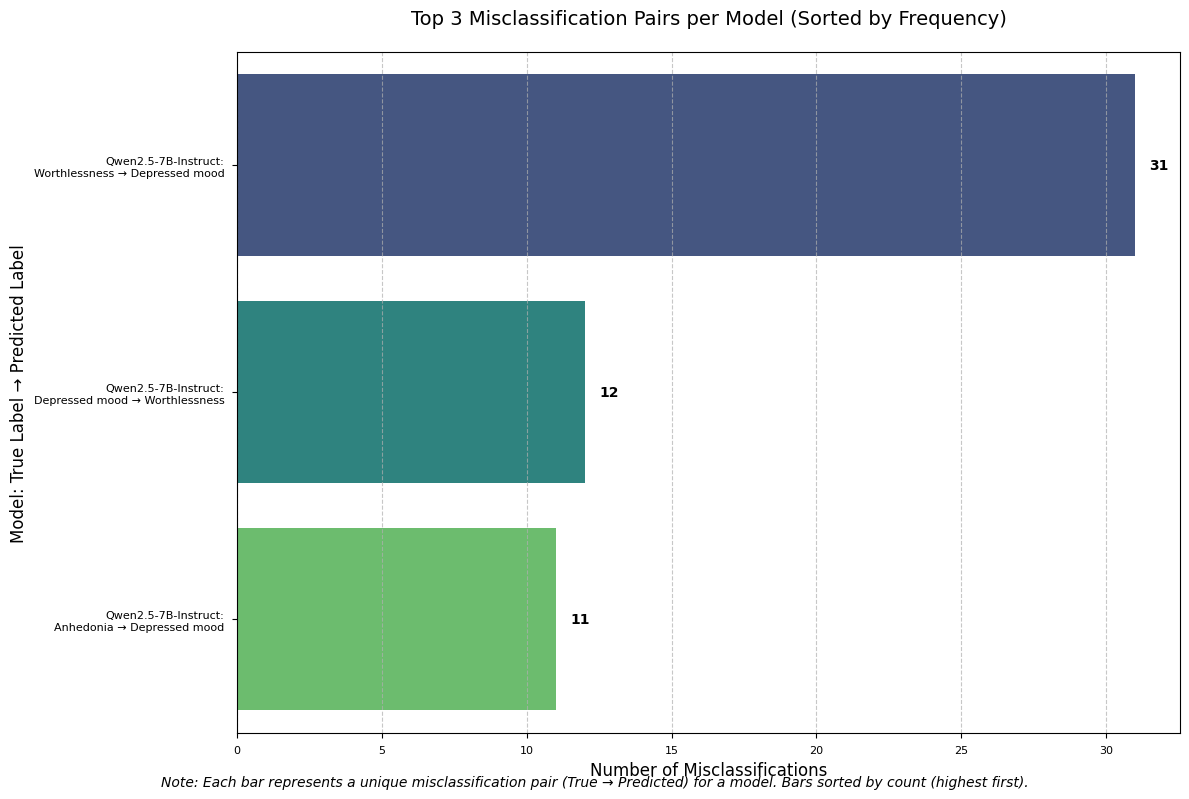

In [278]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Get top 5 misclassifications per model (from previous step)
top_mis = result.groupby('Model').apply(lambda g: g.nlargest(3, 'Count')).reset_index(drop=True)

# Step 2: Create clean labels for visualization
top_mis['Label'] = top_mis.apply(
    lambda x: f"{x['Model']}:\n{str(x['True_Label'])} → {str(x['Predicted_Label'])}", 
    axis=1
)

# Step 3: Sort by count (descending) for better visualization
top_mis = top_mis.sort_values('Count', ascending=False)

# Step 4: Create visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    y='Label', 
    x='Count', 
    data=top_mis,
    palette='viridis',
    orient='h'
)

# Add count labels on bars
for i, v in enumerate(top_mis['Count']):
    ax.text(v + 0.5, i, f'{v}', 
            color='black', 
            fontweight='bold',
            va='center')

# Enhance visualization
plt.title('Top 3 Misclassification Pairs per Model (Sorted by Frequency)', fontsize=14, pad=20)
plt.xlabel('Number of Misclassifications', fontsize=12)
plt.ylabel('Model: True Label → Predicted Label', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Optional: Add a note for clarity
plt.figtext(0.5, 0.01, 
            "Note: Each bar represents a unique misclassification pair (True → Predicted) for a model. "
            "Bars sorted by count (highest first).",
            ha='center', fontsize=10, style='italic')

plt.savefig("top 3 misclassification.png", dpi=300, bbox_inches='tight')
plt.show()
